# AICE Associate 스타일 모의 문항 ① 카시트 판매량 예측

> 공식 **AICE Associate 샘플 문항(14문항)** 의 구성과 요구사항 형식을 참고해 **새로 만든 연습 문제**입니다.
> 실제 시험 문항·데이터와는 다릅니다.

### 문제 상황
카시트를 판매하는 매장 체인의 **매장 정보**와 **판매 실적** 데이터가 두 파일로 나뉘어 있습니다.
두 데이터를 합쳐 전처리한 뒤, 머신러닝과 딥러닝으로 **매장별 판매량(Sales, 천 개)** 을 예측합니다.

| 파일 | 주요 열 |
|---|---|
| `carseats_store.csv` | StoreID, Region(지역), CompPrice(경쟁사 가격), Income(지역 소득), Advertising(광고비), Population(인구), Price(판매가), ShelveLoc(진열 위치), Age(평균 연령), Education, Urban, US, Open_Date(개점일) |
| `carseats_sales.csv` | StoreID, **Sales(판매량, 예측 대상)**, Survey_Date(조사일) |

### 진행 방법
- `# 여기에 답안코드를 작성하세요` 칸에 코드를 작성하고 실행한 뒤, 아래 `check(번호)` 셀로 채점합니다.
- 막히면 `hint(번호)`, 마지막에 `score()` 로 점수를 확인합니다. (14문항, 80점 이상 합격 기준)
- **변수명은 문제에서 지정한 이름을 그대로** 사용하세요. 문항은 앞 문항의 결과를 이어서 사용합니다.
- 같은 폴더에 `aice_grader_carseats.py`, `carseats_store.csv`, `carseats_sales.csv` 가 있어야 합니다.
- 필요 라이브러리: pandas, scikit-learn, seaborn, matplotlib, tensorflow

---
## 📘 해답 노트북

In [1]:
# [준비] 채점 모듈 불러오기 - 먼저 실행하세요
%matplotlib inline
from aice_grader_carseats import check, hint, score, Q4_CHOICES

### 1. scikit-learn 패키지를 사용하기 위해 import 하려고 합니다.
- `sklearn` 을 **sk** 로 import 하세요.

In [2]:
import sklearn as sk

**해설** — 별칭(alias)을 문제에서 지정한 대로 써야 채점됩니다.

In [3]:
check(1)

✅ [문항 1] scikit-learn import — 정답!


### 2. Pandas 는 데이터 분석을 위해 널리 사용되는 파이썬 라이브러리입니다.
- Pandas 를 사용할 수 있도록 **pd** 라는 별칭으로 import 하세요.

In [4]:
import pandas as pd

In [5]:
check(2)

✅ [문항 2] pandas import — 정답!


### 3. 두 개의 데이터 파일을 읽어 하나로 합치려고 합니다.
- `carseats_store.csv` 를 읽어 **df_store** 에 저장하세요.
- `carseats_sales.csv` 를 읽어 **df_sales** 에 저장하세요.
- 두 데이터프레임을 **'StoreID'** 를 기준으로 **inner join** 하여 **df** 에 저장하세요.

In [6]:
df_store = pd.read_csv('carseats_store.csv')
df_sales = pd.read_csv('carseats_sales.csv')
df = pd.merge(df_store, df_sales, on='StoreID', how='inner')
print(df_store.shape, df_sales.shape, df.shape)

(400, 13) (404, 3) (400, 15)


**해설** — `pd.merge` 의 기본값은 `how='inner'` 입니다. 판매 기록에만 있고 매장 정보가 없는 4건은 병합 결과에서 빠집니다.

In [7]:
check(3)

✅ [문항 3] 파일 읽기·병합 — 정답!


### 4. Region(지역) 컬럼의 분포를 확인하려고 합니다.
- **seaborn** 을 **sns** 로 import 하고, `countplot` 으로 df 의 **Region** 분포를 그려 결과를 **ax4** 에 저장하세요.
- 그래프를 보고 아래 보기 중 **옳지 않은** 설명의 번호를 **답안04** 에 저장하세요.
- 그다음, Region 값이 **'-'** 인 행을 삭제하여 다시 **df** 에 저장하세요.

1. North 지역 매장 수가 가장 많다.
2. 지역 정보가 '-' 로 기재된 매장이 있다.
3. East 지역 매장 수가 West 지역 매장 수보다 많다.
4. North 와 South 의 매장 수 차이는 10개 미만이다.


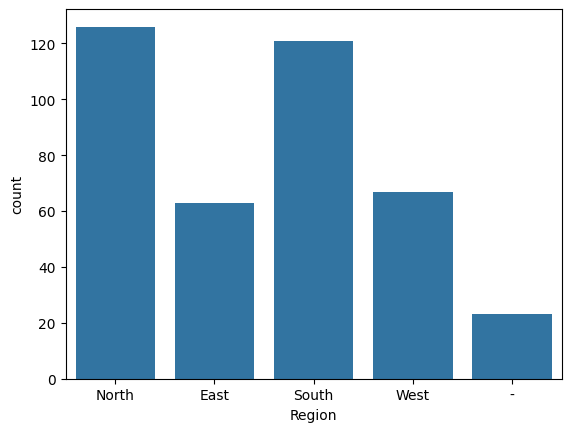

In [8]:
for c in Q4_CHOICES: print(c)

import seaborn as sns
ax4 = sns.countplot(data=df, x='Region')

답안04 = 3
df = df[df['Region'] != '-']

**해설** — 그래프에서 West(67)가 East(63)보다 많으므로 3번이 틀린 설명입니다. 삭제는 그래프를 그린 뒤에 해야 '-' 막대를 볼 수 있습니다.

In [9]:
check(4)

✅ [문항 4] 지역 분포 시각화·'-' 행 삭제 — 정답!


### 5. 판매가(Price)와 판매량(Sales)의 관계를 확인하려고 합니다.
- seaborn 의 `jointplot` 을 사용하여 **x축은 Price, y축은 Sales** 인 그래프를 그리고, 결과를 **g5** 에 저장하세요.

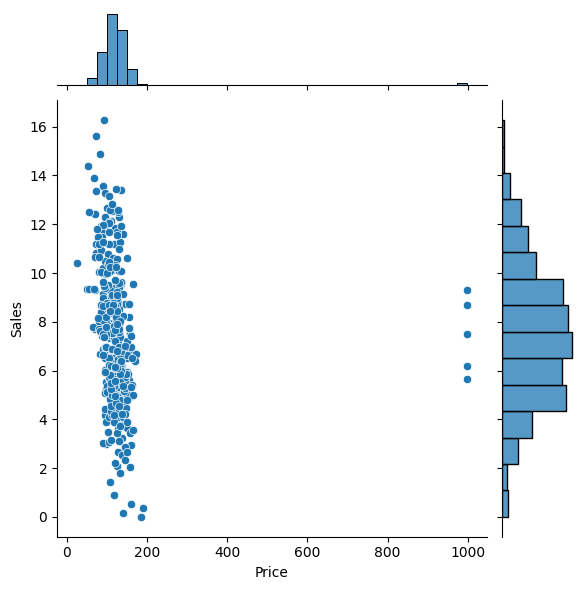

In [10]:
g5 = sns.jointplot(data=df, x='Price', y='Sales')

**해설** — 오른쪽 끝(Price=999)에 떨어져 있는 점들이 입력 오류로 보이는 이상치입니다. 다음 문항에서 삭제합니다.

In [11]:
check(5)

✅ [문항 5] 가격-판매량 jointplot — 정답!


### 6. 문항 5의 그래프에서 가격이 비정상적으로 높은 이상치가 확인됩니다.
- df 에서 **Price 가 300 이상**인 행을 삭제하세요.
- 분석에 필요 없는 **'StoreID'** 컬럼을 삭제하세요.
- 결과를 **df_temp** 에 저장하세요.

In [12]:
df_temp = df[df['Price'] < 300].drop(columns='StoreID')
print(df_temp.shape)

(372, 14)


**해설** — 조건으로 남길 행을 고르는 방식(`< 300`)이 가장 간단합니다.

In [13]:
check(6)

✅ [문항 6] 이상치 삭제·열 삭제 — 정답!


### 7. 결측치를 처리하려고 합니다.
- df_temp 의 **전체 결측치 개수**(숫자 하나)를 **답안07** 에 저장하세요.
- 결측치가 있는 행을 삭제하여 **df_na** 에 저장하세요.

In [14]:
print(df_temp.isnull().sum())
답안07 = df_temp.isnull().sum().sum()
df_na = df_temp.dropna()
print(답안07, df_na.shape)

Region         0
CompPrice      0
Income         7
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            6
Education      0
Urban          0
US             0
Open_Date      0
Sales          0
Survey_Date    0
dtype: int64
13 (359, 14)


**해설** — 열별 개수는 `isnull().sum()`, 전체 합계는 `.sum()` 을 한 번 더 합니다.

In [15]:
check(7)

✅ [문항 7] 결측치 확인·삭제 — 정답!


### 8. 분석에 불필요한 날짜 컬럼을 삭제하려고 합니다.
- df_na 에서 **'Open_Date', 'Survey_Date'** 컬럼을 삭제하여 **df_del** 에 저장하세요.

In [16]:
df_del = df_na.drop(columns=['Open_Date', 'Survey_Date'])

In [17]:
check(8)

✅ [문항 8] 불필요한 열 삭제 — 정답!


### 9. 모델링을 위해 범주형 데이터를 수치로 변환하려고 합니다.
- df_del 의 **object 타입 컬럼 전체**를 대상으로 pandas 의 `get_dummies` 를 사용해 원-핫 인코딩하세요.
- 결과를 **df_preset** 에 저장하세요.

In [18]:
obj_cols = df_del.select_dtypes('object').columns
print(list(obj_cols))
df_preset = pd.get_dummies(df_del, columns=obj_cols)

['Region', 'ShelveLoc', 'Urban', 'US']


**해설** — Region, ShelveLoc, Urban, US 네 열이 인코딩됩니다. `columns=` 를 생략해도 object 열이 자동으로 변환됩니다.

In [19]:
check(9)

✅ [문항 9] 원-핫 인코딩 — 정답!


### 10. 훈련과 검증 데이터를 나누고 스케일링하려고 합니다.
- 대상 데이터프레임: df_preset / 예측 대상(y): **'Sales'** / 나머지 컬럼은 X
- train : validation = **80 : 20**, **random_state = 42**
- 결과 변수: **X_train, X_valid, y_train, y_valid**
- **RobustScaler** 를 사용해 X_train 은 `fit_transform`, X_valid 는 `transform` 한 결과를 **각각 X_train, X_valid 에 다시 저장**하세요.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df_preset.drop(columns='Sales')
y = df_preset['Sales']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_valid = rs.transform(X_valid)
print(X_train.shape, X_valid.shape)

(287, 18) (72, 18)


**해설** — RobustScaler 는 중앙값과 IQR 을 기준으로 스케일링해서 이상치의 영향을 덜 받습니다. valid 는 다시 fit 하지 않습니다.

In [21]:
check(10)

✅ [문항 10] 데이터 분할·RobustScaler — 정답!


### 11. 판매량을 예측하는 머신러닝 모델을 만들려고 합니다.
- **DecisionTreeRegressor** 를 **dt** 에, **RandomForestRegressor** 를 **rf** 에 저장하세요.
- 두 모델 모두 하이퍼파라미터: **max_depth=5, min_samples_split=3, random_state=120**
- 두 모델을 X_train, y_train 으로 학습하세요.

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = DecisionTreeRegressor(max_depth=5, min_samples_split=3, random_state=120)
dt.fit(X_train, y_train)
rf = RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [23]:
check(11)

✅ [문항 11] DT·RF 모델 학습 — 정답!


### 12. 두 모델의 성능을 평가하려고 합니다.
- 검증 데이터(X_valid, y_valid)로 **MAE(Mean Absolute Error)** 를 계산하여 **dt_mae, rf_mae** 에 저장하세요.
- 성능이 더 좋은 모델을 **'dt'** 또는 **'rf'** 문자열로 **답안12** 에 저장하세요.

In [24]:
from sklearn.metrics import mean_absolute_error

dt_mae = mean_absolute_error(y_valid, dt.predict(X_valid))
rf_mae = mean_absolute_error(y_valid, rf.predict(X_valid))
print('DT MAE:', round(dt_mae, 3), '| RF MAE:', round(rf_mae, 3))

답안12 = 'rf' if rf_mae < dt_mae else 'dt'

DT MAE: 1.999 | RF MAE: 1.421


**해설** — MAE 는 오차의 평균이라 **작을수록** 좋습니다. 조건식으로 답하면 결과가 바뀌어도 맞게 됩니다.

In [25]:
check(12)

✅ [문항 12] MAE 평가·모델 비교 — 정답!


### 13. 판매량을 예측하는 딥러닝 모델을 만들려고 합니다.
- Tensorflow 의 **Sequential** 모델로 만들고 **model** 에 저장하세요.
- 히든 레이어(hidden layer) **2개 이상**, **Dropout 비율 0.2** 레이어 1개 이상
- 출력층은 값 1개를 예측하는 Dense 층
- **loss='mse', metrics=['mse']** 로 compile 하세요.
- **epochs=30, batch_size=16** 으로 학습하고, 검증 데이터로 **X_valid, y_valid** 를 사용하세요.
- 학습 결과(`fit` 의 반환값)를 **history** 에 저장하세요.

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

tf.random.set_seed(42)
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1),
])
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = model.fit(X_train, y_train, epochs=30, batch_size=16,
                    validation_data=(X_valid, y_valid), verbose=0)

**해설** — 회귀 출력층에는 활성화 함수를 쓰지 않습니다(`Dense(1)`). `verbose=0` 은 학습 로그를 숨깁니다.

In [27]:
check(13)

✅ [문항 13] 딥러닝 모델 학습 — 정답!


### 14. 딥러닝 모델의 학습 과정을 시각화하려고 합니다.
- history 의 **mse** 와 **val_mse** 를 한 그래프에 그리세요. (x축: epoch)
- 범례 이름은 각각 **'mse', 'val_mse'** 로 지정하세요.
- 그래프를 그린 셀 끝에서 `plt.show()` **이전에** **ax14 = plt.gca()** 로 축을 저장하세요.

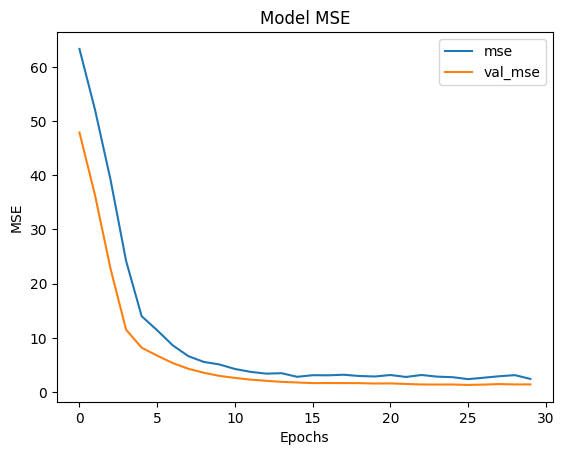

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['mse'], label='mse')
plt.plot(history.history['val_mse'], label='val_mse')
plt.xlabel('Epochs'); plt.ylabel('MSE'); plt.title('Model MSE')
plt.legend()
ax14 = plt.gca()
plt.show()

**해설** — 두 곡선이 함께 내려가면 정상입니다. mse 만 내려가고 val_mse 가 올라가면 과적합입니다.

In [29]:
check(14)

✅ [문항 14] 학습 곡선 시각화 — 정답!


## 최종 점수

In [30]:
score()

 ✅ 문항  1  scikit-learn import
 ✅ 문항  2  pandas import
 ✅ 문항  3  파일 읽기·병합
 ✅ 문항  4  지역 분포 시각화·'-' 행 삭제
 ✅ 문항  5  가격-판매량 jointplot
 ✅ 문항  6  이상치 삭제·열 삭제
 ✅ 문항  7  결측치 확인·삭제
 ✅ 문항  8  불필요한 열 삭제
 ✅ 문항  9  원-핫 인코딩
 ✅ 문항 10  데이터 분할·RobustScaler
 ✅ 문항 11  DT·RF 모델 학습
 ✅ 문항 12  MAE 평가·모델 비교
 ✅ 문항 13  딥러닝 모델 학습
 ✅ 문항 14  학습 곡선 시각화
----------------------------------------------
 정답 14 / 14  →  100.0점  합격 (기준 80점)
